In [181]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
!python -m pip install plotnine
from plotnine import *
import seaborn as sns
import scipy.stats.stats as stats
!python -m pip install pingouin
import pingouin as pg
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

In [114]:
gpt2_df = pd.read_csv(r'data\GPT2-large-dimensions.csv')

In [115]:
gpt2_df.head(3)

,Social.Category,Source,gender.main,gender_norm.main,gender.ext,gender_norm.ext,gender.red,gender_norm.red,age.main,age_norm.main,age.ext,age_norm.ext,age.red,age_norm.red
0,abandoned infant,GPT2,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423
1,abandoned person,GPT2,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159
2,abiogenist,GPT2,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863


In [116]:
gpt2_df.drop(columns='Source', inplace=True)

In [117]:
columns = ['social_category', 'gender_main', 'gender_norm_main', 'gender_ext', 'gender_norm_ext', 
            'gender_red', 'gender_norm_red', 'age_main', 'age_norm_main', 'age_ext', 
            'age_norm_ext', 'age_red', 'age_norm_red']

gpt2_df.columns = columns

## Correlation Between Age and Gender

In [118]:
pg.corr(gpt2_df['gender_norm_main'], gpt2_df['age_norm_main'])

,n,r,CI95,p_val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


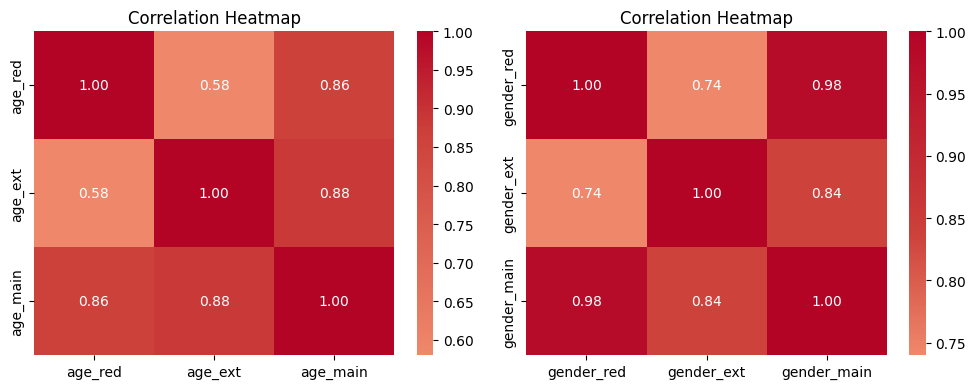

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
heatmap_age_data = gpt2_df[['age_red', 'age_ext', 'age_main']].corr()
colors = [(0, '#ef886b'), (0.69, '#cc403a'), (1.00, '#b40426')]
cmap_age = LinearSegmentedColormap.from_list('my_cmap', colors)
sns.heatmap(heatmap_age_data, annot=True, fmt='.2f', cmap=cmap_age, vmin=0.58, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

heatmap_gender_data = gpt2_df[['gender_red', 'gender_ext', 'gender_main']].corr()
colors = [(0, '#ef886b'), (0.38, '#cc403a'), (1.00, '#b40426')]
cmap_gender = LinearSegmentedColormap.from_list('my_cmap', colors)
sns.heatmap(heatmap_gender_data, annot=True, fmt='.2f', cmap=cmap_gender, vmin=0.74, ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Relationship between Age and Gender

In [205]:
gpt2_df.head(3)

,social_category,gender_main,gender_norm_main,gender_ext,gender_norm_ext,gender_red,gender_norm_red,age_main,age_norm_main,age_ext,age_norm_ext,age_red,age_norm_red,perceived_job_type
0,abandoned infant,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423,normal
1,abandoned person,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159,normal
2,abiogenist,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863,normal


In [121]:
age_gender_mod = smf.ols("age_norm_main ~ gender_norm_main", data=gpt2_df)
age_gender_res = age_gender_mod.fit()
age_gender_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:02:55   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [224]:
gpt2_df['perceived_job_type'] = np.select(
    [
        gpt2_df['social_category'].isin([
            'elected official',
            'military personnel',
            'chief of staff',
            'chairman of the board',
            'director of research'
        ]),
        gpt2_df['social_category'].isin([
            'intern',
            'homoepath',
            'cook',
            'secretary',
            'novice'
        ])
    ],
    ['masculine', 'feminine'],
    default='normal'
)

colors = {
    'masculine':'#61b1ff',
    'feminine':'#e5c062',
    'normal':'lightgrey'
}

sizes = {
    'masculine': 11,
    'feminine': 11,
    'normal': 6
}

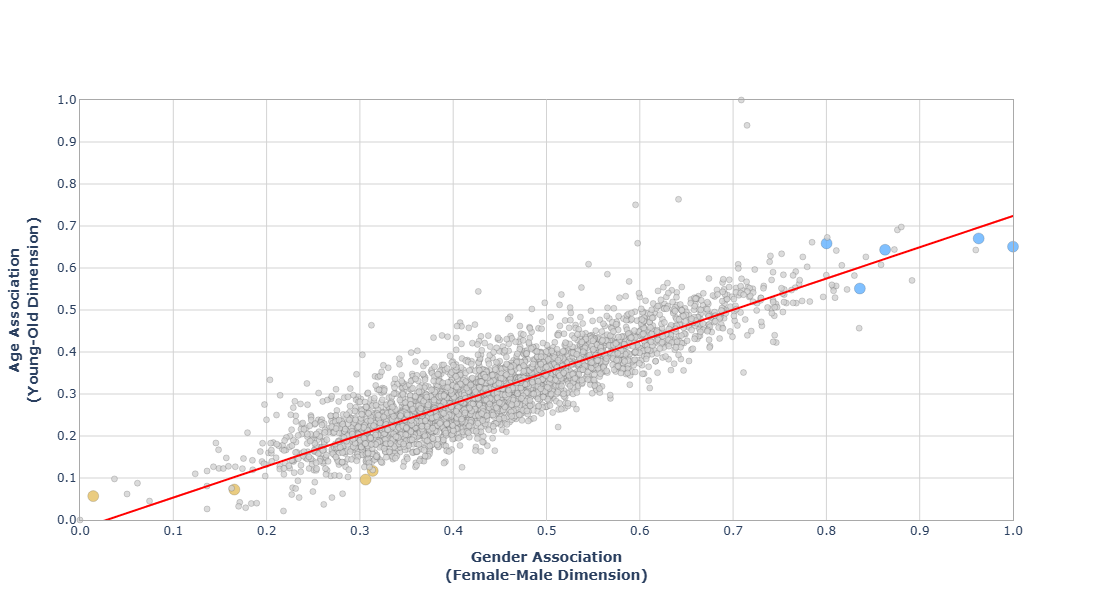

In [255]:
fig = go.Figure()

#scatter-plot section
for job_type, color in colors.items():
    subset = gpt2_df[gpt2_df['perceived_job_type'] == job_type]
    fig.add_trace(go.Scatter(
        x=subset['gender_norm_main'],
        y=subset['age_norm_main'],
        mode="markers",
        marker=dict(color=color, opacity=0.8, size=sizes[job_type], line=dict(width=0.2, color="black")),
        customdata=subset[['social_category', 'gender_norm_main', 'age_norm_main']],
        hovertemplate=(
            "<span style='color:grey'>social_category:</span> %{customdata[0]}<br>"
            "<span style='color:grey'>gender_norm:</span> %{customdata[1]:.2f}<br>"
            "<span style='color:grey'>age_norm:</span> %{customdata[2]:.2f}"
            "<extra></extra>"
        ),
        showlegend=False,
        cliponaxis=False
    ))

#trend line section
trendline_trace = px.scatter(gpt2_df, x='gender_norm_main', y='age_norm_main', trendline="ols").data[1]
trendline_trace.line.color = "red"
fig.add_trace(trendline_trace)

#formating section
axis_style = dict(
    showgrid=True, gridcolor="lightgrey",
    showline=True, linecolor="darkgrey",
    mirror=True, dtick=0.1, tickformat=".1f",
    range=[0, 1]
)

fig.update_layout(
    width=600, height=600,
    plot_bgcolor="white",
    xaxis=dict(title="<b>Gender Association<br>(Female-Male Dimension)</b>", **axis_style),
    yaxis=dict(title="<b>Age Association<br>(Young-Old Dimension)</b>", **axis_style),
    hoverlabel=dict(bgcolor="white", bordercolor="grey", font=dict(family="Arial", size=11, color="black"))
)

fig.show(config=dict(
    displayModeBar=True,
    modeBarButtonsToRemove=[
        'zoom2d', 'pan2d', 'select2d', 'lasso2d',
        'zoomIn2d', 'zoomOut2d', 'autoScale2d', 'resetScale2d'
    ],
    displaylogo=False
))

In [262]:
fig = alt.Chart(gpt2_df).mark_point(filled=True).encode(
    x='gender_norm_main',
    y='age_norm_main',
    color='perceived_job_type'
)
final_plot = fig + fig.transform_regression('gender_norm_main', 'age_norm_main').mark_line(color='red')
final_plot.show()

alt.LayerChart(...)